# Project Random Forest

For this project, we will be exploring publicly available data from [LendingClub.com](www.lendingclub.com). Lending Club connects people who need money (borrowers) with people who have money (investors). Fortunately, as an investor, you would like to invest in people who have shown a profile of having a high probability of paying you back. Let's try to create a model that helps predict this.

The loan club had a [very interesting year in 2016](https://en.wikipedia.org/wiki/Lending_Club#2016), so let's check some of their data and keep the context in mind. This data is from before it was even public.

We will use loan data from 2007-2010 and try to classify and predict whether the borrower has paid back the loan in full. You can download the data from [here](https://www.lendingclub.com/info/download-data.action) or just use the csv already provided. It is recommended that you use the csv provided as it has been cleaned of NA values.

Here's what the columns represent:
* credit.policy: 1 if the customer meets LendingClub.com's credit underwriting criteria and 0 otherwise.
* purpose: The purpose of the loan (possible values “credit_card”, “debt_consolidation”, “educational”, “major_purchase”, “small_business” and “all_other”).
* int.rate: the interest rate of the loan (a rate of 11% would be stored as 0.11). Borrowers judged by LendingClub.com to be riskier receive higher interest rates.
* installment: the monthly installments due by the borrower if the loan is financed.
* log.annual.inc: The natural log of the borrower's self-reported annual income.
* dti: Borrower's debt/income ratio (debt amount divided by annual income).
* fico: the borrower's FICO credit score.
* days.with.cr.line: The number of days the borrower has had a credit line.
* revol.bal: borrower's revolving balance (amount unpaid at the end of the credit card billing cycle).
* revol.util: borrower's revolving line utilization rate (the value of the credit line used in relation to the total credit available).
* inq.last.6mths: number of inquiries the borrower has had from creditors in the last 6 months.
* delinq.2yrs: the number of times the borrower had spent more than 30 days on a payment in the last 2 years.
* pub.rec: The number of public records derogatory to the borrower (bankruptcy filings, tax liens or judgments).

In [15]:
loans['not.fully.paid'].value_counts()

not.fully.paid
0    8045
1    1533
Name: count, dtype: int64

# Import libs

** Import the usual libraries for pandas and plotting. You can import sklearn later. **

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Obtain data

** Use pandas to read loan_data.csv as a DataFrame called loans. **

In [2]:
loans = pd.read_csv('loan_data.csv')

** Use methods info(), head(), and describe() in loans. **

In [3]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [4]:
loans.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


# Exploratory data analysis 

Let's do some data visualization! We'll use the plotting features built into seaborn and pandas, but feel free to use any library you like. Don't worry about the colors, just worry about getting the main idea of the plot.

** Create a histogram of two FICO distributions on top of each other, one for each of the possible values of credit.policy **.

* Note: This is complicated, feel free to reference the solutions. You'll probably need a line of code for each histogram, I also recommend using the .hist() built into pandas. *

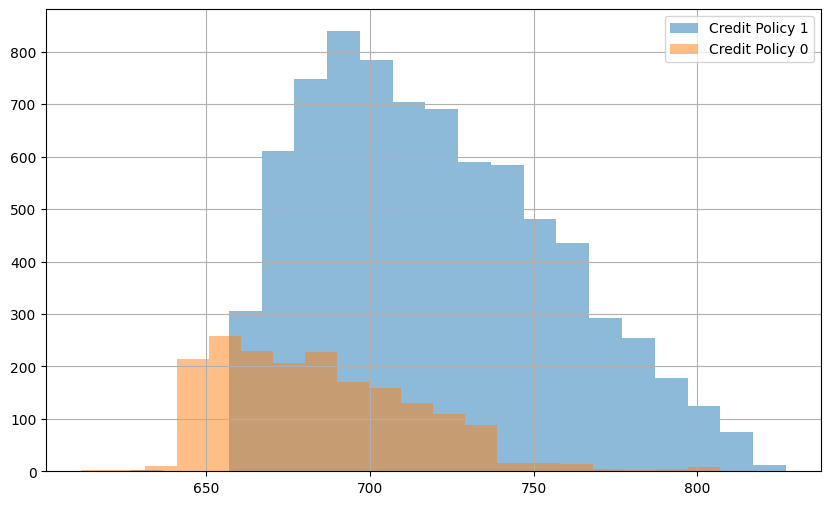

In [5]:
plt.figure(figsize=(10,6))
loans[loans['credit.policy'] == 1]['fico'].hist(alpha=0.5, bins=20, label='Credit Policy 1')
loans[loans['credit.policy'] == 0]['fico'].hist(alpha=0.5, bins=20, label='Credit Policy 0')
plt.legend()

** Create a similar chart, but this time use the column not.fully.paid. **

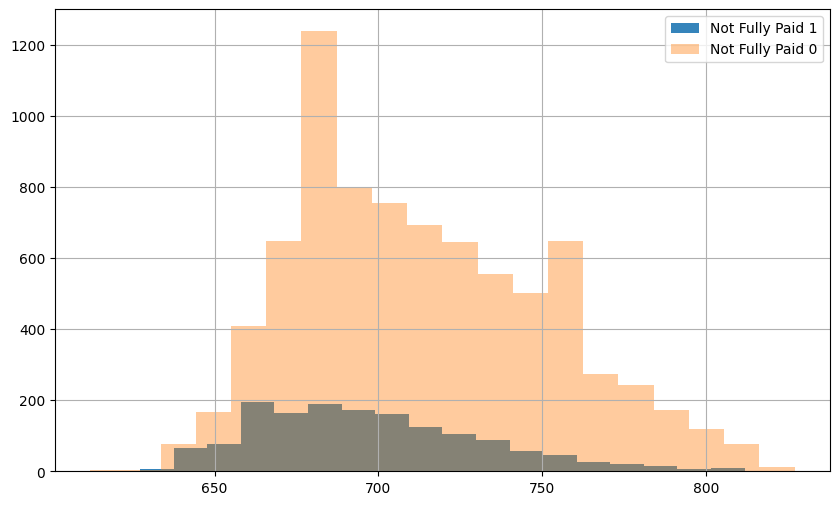

In [6]:
plt.figure(figsize=(10, 6))
loans[loans['not.fully.paid'] == 1]['fico'].hist(alpha=0.9, bins=20, label='Not Fully Paid 1')
loans[loans['not.fully.paid'] == 0]['fico'].hist(alpha=0.4, bins=20, label='Not Fully Paid 0')
plt.legend()

** Create a countplot using seaborn showing loan count by purpose, with the color hue defined by not.fully.paid. **

<Axes: xlabel='purpose', ylabel='count'>

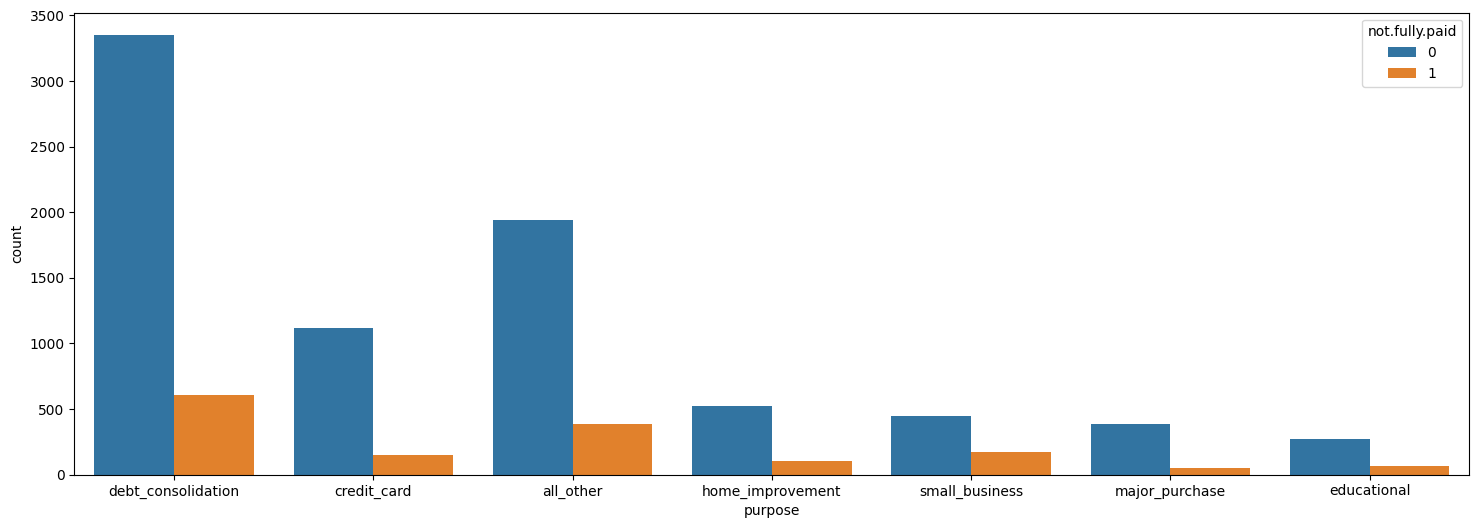

In [7]:
plt.figure(figsize=(18,6))
sns.countplot(x='purpose', hue='not.fully.paid', data=loans)

** Look at tendency between FICO index and interest rate. Recreate the following jointplot. **

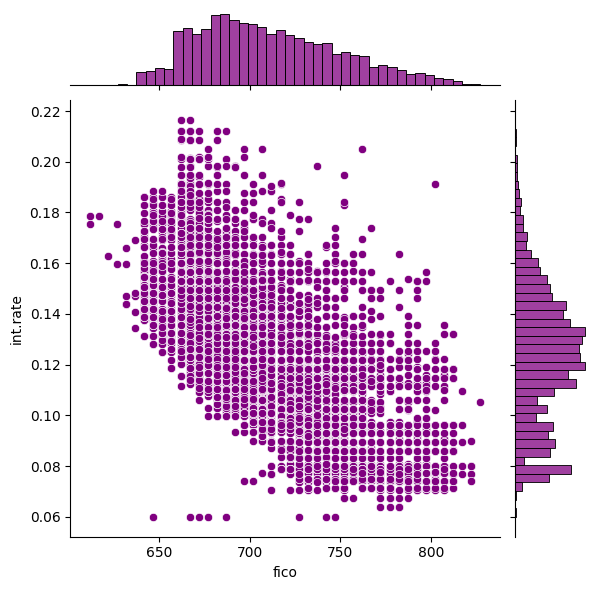

In [8]:
sns.jointplot(x='fico', y='int.rate', data=loans, color='purple')
# tendency for people with higher FICO scores to receive a lower interest rate

** Create the following lmplots to see if the trend differed between not.fully.paid and credit.policy. Check the documentation for lmplot() if you can't figure out how to separate it into columns. **

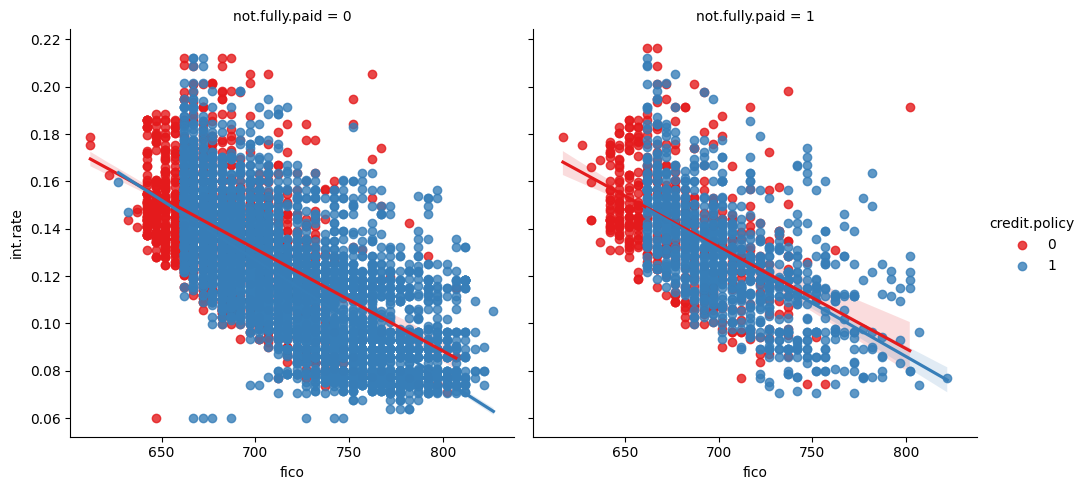

In [9]:
sns.lmplot(y='int.rate', x='fico', data=loans, hue='credit.policy',
           col='not.fully.paid', palette='Set1')

plt.show()

# Configurating data

Let's get ready to configure our data for our random forest classification model!

** Check loans.info() again. **

In [10]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [11]:
loans['purpose'].value_counts()

purpose
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: count, dtype: int64

## Categorical resources

Let's turn the ***purpose*** column into a categorical one.
This means that we need to transform them using dummies so that Sklearn can understand them. We'll do this in a cleanup step using pd.get_dummies.

** Create a list of 1 element containing the string 'purpose'. Call this list cat_feats. **

In [12]:
# the practice of taking a column and calling it a list to pick and run 
cat_features = ['purpose']

** Now use “pd.get_dummies(loans, columns = cat_feats, drop_first = True)” to create a larger fixed DataFrame that has new resource columns with dummy variables. Call this dataframe final_data. **

In [13]:
# get dummies: receives a dataframe and needs one or more columns to turn into dummies
# drop first: so as not to exclude the original value
df_final = pd.get_dummies(loans, columns=cat_features, drop_first=True) 

## Split Train-Test Data

Now it's time to split our data into a training set and a test set!

** Use sklearn to split your data into a training set and a test set as we have done in the past. **

In [14]:
from sklearn.model_selection import train_test_split

## Training a Decision Tree Model

Let's start training one decision tree first!

** Import DecisionTreeClassifier **

In [15]:
X = df_final.drop('not.fully.paid', axis=1)
y = df_final['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

** Create an instance of DecisionTreeClassifier() called dtree and load it with the training data. **

In [17]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

## Forecasts and decision tree evaluation
** Make predictions from the test set and create a classification report and confusion matrix. **

In [18]:
predictions = dtree.predict(X_test)

## Training Random Forest model

Now it's time to training our model!

** Create an instance of the RandomForestClassifier class and adjust it to our training data from the previous step. **

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from scipy import stats

In [27]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.86      0.81      0.83      2431
           1       0.19      0.24      0.22       443

    accuracy                           0.73      2874
   macro avg       0.52      0.53      0.52      2874
weighted avg       0.75      0.73      0.74      2874



In [28]:
cm = confusion_matrix(y_test, predictions)
cm

array([[1980,  451],
       [ 335,  108]])

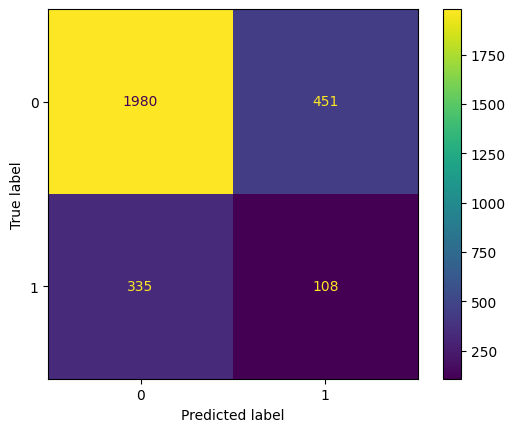

In [29]:
ConfusionMatrixDisplay(confusion_matrix=cm,).plot();

In [30]:
# Calculating the probabilities
y_prob = dtree.predict_proba(X_test)[:, 1]  # Probabilidade de y = 1

In [31]:
# Calculate  Sensitivity (True Positive Rate = TPR) and also Specificity (False Positive Rate = FPR)
# To calculate the curve we need Target (Y Actual) and the probability of chosen model [ Prob (Y = 1) ]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

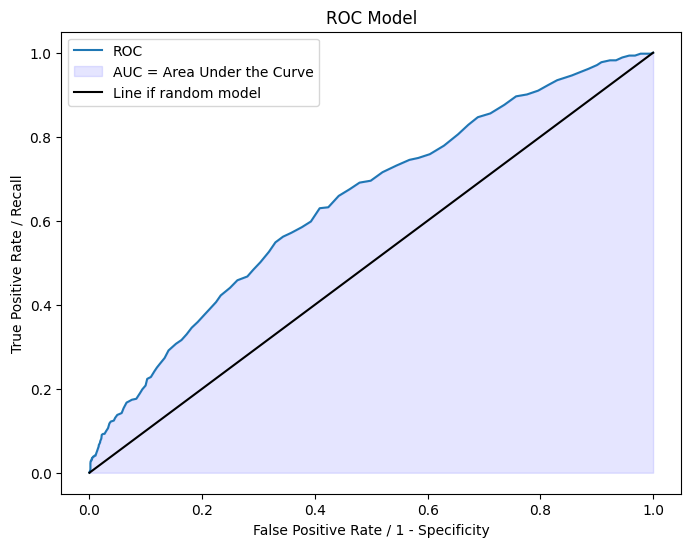

In [60]:
plt.figure(figsize=(8,6))

plt.plot(fpr,tpr, label='ROC')
plt.fill_between(fpr,tpr,color='blue',alpha= 0.1,label = 'AUC = Area Under the Curve')
plt.plot(np.linspace(0,1,100),np.linspace(0,1,100),color='black',label='Line if random model')

plt.title("ROC Model")
plt.ylabel('True Positive Rate / Recall')
plt.xlabel('False Positive Rate / 1 - Specificity')
plt.legend();

In [33]:
# Calculate the area under the curve ROC
roc_auc_score(y_test, y_prob)

np.float64(0.5291359815327416)

In [35]:
ks_data = pd.DataFrame({
    'y_test': y_test,
    'y_prob': y_prob
})

In [36]:
# Split the possibilities according to the real value from y_test
prob_y_real_0 = ks_data.loc[ks_data['y_test'] == 0, 'y_prob']
prob_y_real_1 = ks_data.loc[ks_data['y_test'] == 1, 'y_prob']

In [37]:
# You can calculate the cumulated distribution and the KS
from scipy.stats import ks_2samp

# KS
ks_stat, ks_p_value = ks_2samp(prob_y_real_1, prob_y_real_0)

print(f"KS Statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p_value:.4f}")

KS Statistic: 0.0583
p-value: 0.1501


# Your model performs almost like a random model. It is not suitable for solving this problem.
# There is not enough statistical evidence to conclude that the two distributions are different.


## Forecasts and Evaluation

Let's predict the y_test values and evaluate our model.

** Predict the not.fully.paid class for the X_test data. **

In [38]:
from sklearn.ensemble import RandomForestClassifier


In [39]:
rfc = RandomForestClassifier(n_estimators=200)

In [40]:
rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200)

In [41]:
predictions = rfc.predict(X_test)

** Now create a report ranking the results.**

In [42]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2431
           1       0.65      0.03      0.06       443

    accuracy                           0.85      2874
   macro avg       0.75      0.51      0.49      2874
weighted avg       0.82      0.85      0.78      2874



** Show the Confusion Matrix for the predictions. **

In [43]:
cm = confusion_matrix(y_test, predictions)
cm

array([[2424,    7],
       [ 430,   13]])

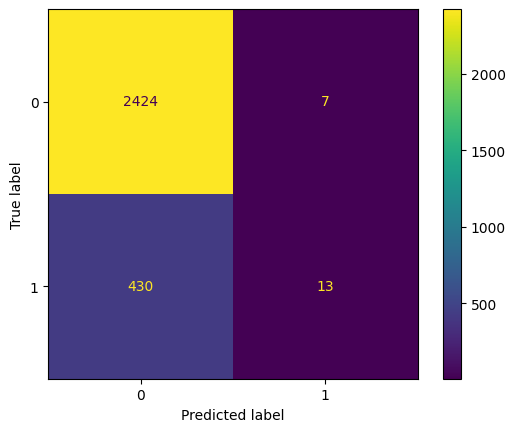

In [44]:
ConfusionMatrixDisplay(confusion_matrix=cm,).plot();

In [45]:
# Calculating the probabilities
y_prob = rfc.predict_proba(X_test)[:, 1]  # Probabilidade de y = 1

In [46]:
# Calculate  Sensitivity (True Positive Rate = TPR) and also Specificity (False Positive Rate = FPR)
# To calculate the curve we need Target (Y Actual) and the probability of chosen model [ Prob (Y = 1) ]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

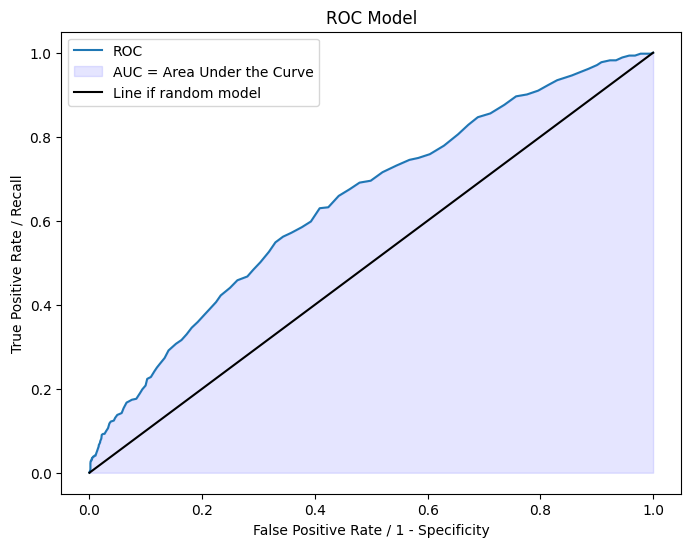

In [61]:
plt.figure(figsize=(8,6))

plt.plot(fpr,tpr, label='ROC')
plt.fill_between(fpr,tpr,color='blue',alpha= 0.1,label = 'AUC = Area Under the Curve')
plt.plot(np.linspace(0,1,100),np.linspace(0,1,100),color='black',label='Line if random model')

plt.title("ROC Model")
plt.ylabel('True Positive Rate / Recall')
plt.xlabel('False Positive Rate / 1 - Specificity')
plt.legend();

In [48]:
# Calculate the area under the curve ROC
roc_auc_score(y_test, y_prob)

np.float64(0.6436639976674501)

In [49]:
ks_data = pd.DataFrame({
    'y_test': y_test,
    'y_prob': y_prob
})

In [50]:
# Split the possibilities according to the real value from y_test
prob_y_real_0 = ks_data.loc[ks_data['y_test'] == 0, 'y_prob']
prob_y_real_1 = ks_data.loc[ks_data['y_test'] == 1, 'y_prob']

In [51]:
# You can calculate the cumulated distribution and the KS
from scipy.stats import ks_2samp

# KS
ks_stat, ks_p_value = ks_2samp(prob_y_real_1, prob_y_real_0)

print(f"KS Statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p_value:.4f}")

KS Statistic: 0.2213
p-value: 0.0000


# A KS value of 0.2213, combined with such a low p-value, suggests that your Random Forest model has an excellent ability to discriminate between positive and negative classes. This means that the model manages to separate individuals belonging to one class from those belonging to the other very well.

** Which performed better: the random forest or the decision tree? **

In [ ]:
# The Random Forest outperforms the Decision Tree, but it is not yet an ideal model. It is moderately effective, but improvements can be made.